In [1]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers
import tensorflow as tf

In [2]:
IMG_SIZE = 180

resize_and_rescale = tf.keras.Sequential([
    layers.Resizing(IMG_SIZE, IMG_SIZE),
    layers.Rescaling(1./255)
])

In [3]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal_and_vertical'),
    layers.RandomRotation(0.2)
])

In [4]:
model = tf.keras.Sequential([
    resize_and_rescale,
    data_augmentation,

    #model
    layers.Conv2D(16, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten()
])

17858/17858 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


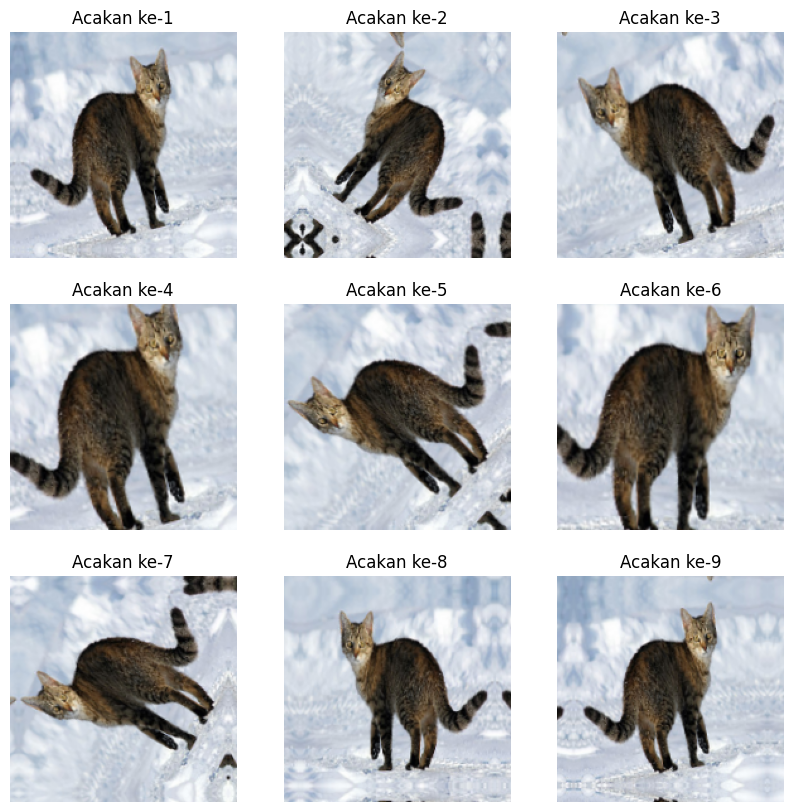

In [5]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers

# =================================================================
# 1. AMBIL 1 GAMBAR (Kucing di atas salju)
# =================================================================
url = "https://storage.googleapis.com/download.tensorflow.org/example_images/320px-Felis_catus-cat_on_snow.jpg"
image_path = tf.keras.utils.get_file("cat_snow.jpg", origin=url)

# Baca gambar dan ubah jadi angka array (ukuran 180x180)
img = tf.keras.utils.load_img(image_path, target_size=(180, 180))
img_array = tf.keras.utils.img_to_array(img)

# Tambahkan dimensi 'batch' (Karena TensorFlow selalu memproses data secara rombongan/batch)
img_array = tf.expand_dims(img_array, 0) 

# =================================================================
# 2. BUAT MESIN PENGACAK (Data Augmentation)
# =================================================================
data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal"), # Membolak-balik kiri-kanan
  layers.RandomRotation(0.2),      # Memutar miring maksimal 20%
  layers.RandomZoom(0.2),          # Menge-zoom maksimal 20%
])

# =================================================================
# 3. TAMPILKAN HASILNYA SEPERTI ALBUM FOTO (Grid 3x3)
# =================================================================
plt.figure(figsize=(10, 10))

for i in range(9):
  # Masukkan gambar 1 ekor kucing tadi ke mesin pengacak berkali-kali!
  augmented_image = data_augmentation(img_array)
  
  ax = plt.subplot(3, 3, i + 1)
  
  # Tampilkan hasilnya kembali menjadi wujud gambar
  plt.imshow(augmented_image[0].numpy().astype("uint8"))
  plt.title(f"Acakan ke-{i+1}")
  plt.axis("off")

plt.show()

# PEMROSESAN DATA BAHASA

In [37]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

sentences = ['I love my cat']

tokenizer = Tokenizer(num_words = 100)
tokenizer.fit_on_texts(sentences)
sequences = tokenizer.texts_to_sequences(sentences)

print(tokenizer.word_index)
print(sequences)

{'i': 1, 'love': 2, 'my': 3, 'cat': 4}
[[1, 2, 3, 4]]


In [40]:
new_sentences = ['I love my cat', 'Do you think my cat is cute?']

tokenizer = Tokenizer(num_words = 100, oov_token='<00V>')
tokenizer.fit_on_texts(new_sentences)
new_sentences = ['I love my cat', 'Do you think my cat is cute?', 'Additional cat for you']
sequences = tokenizer.texts_to_sequences(new_sentences)

padded = pad_sequences(sequences, padding = "post", truncating="post", maxlen=10)
print("tokenizer : ", tokenizer.word_index)
print('Sequences : ', sequences)
print('Padded : ', padded)

tokenizer :  {'<00V>': 1, 'my': 2, 'cat': 3, 'i': 4, 'love': 5, 'do': 6, 'you': 7, 'think': 8, 'is': 9, 'cute': 10}
Sequences :  [[4, 5, 2, 3], [6, 7, 8, 2, 3, 9, 10], [1, 3, 1, 7]]
Padded :  [[ 4  5  2  3  0  0  0  0  0  0]
 [ 6  7  8  2  3  9 10  0  0  0]
 [ 1  3  1  7  0  0  0  0  0  0]]


# STUDI KASUS 


Tim Data Scientist kita sudah menyiapkan modelnya, tapi mereka butuh bantuanmu untuk membangun Sistem Pra-pemrosesan Teks dari nol. Mereka menolak bekerja dengan teks mentah dan memintamu mengubah ulasan tersebut menjadi matriks angka yang rapi.

Ini adalah data sampel yang berhasil ditarik dari database kita:

In [65]:
kamus_ulasan = ["Makanannya enak dan kurirnya cepat", "Aplikasi sering error saat mau bayar", "Kecewa porsinya sedikit tidak sesuai foto", "Sangat puas dengan layanan TechBite"]
tokenizer = Tokenizer(num_words = 50, oov_token='<00V>')
tokenizer.fit_on_texts(kamus_ulasan)
kamus_ulasan =  ["Makanannya enak dan kurirnya cepat", "Aplikasi sering error saat mau bayar", "Kecewa porsinya sedikit tidak sesuai foto", "Sangat puas dengan layanan TechBite", "Makanannya sudah dingin dan kurirnya lambat", "Banyak promo diskon yang menarik"]
sequences = tokenizer.texts_to_sequences(kamus_ulasan)

padded = pad_sequences(sequences, padding='pre', truncating='pre', maxlen=8)

print("Tokenizer : ",tokenizer.word_index)
print("Sequences : ", sequences)
print(padded)

Tokenizer :  {'<00V>': 1, 'makanannya': 2, 'enak': 3, 'dan': 4, 'kurirnya': 5, 'cepat': 6, 'aplikasi': 7, 'sering': 8, 'error': 9, 'saat': 10, 'mau': 11, 'bayar': 12, 'kecewa': 13, 'porsinya': 14, 'sedikit': 15, 'tidak': 16, 'sesuai': 17, 'foto': 18, 'sangat': 19, 'puas': 20, 'dengan': 21, 'layanan': 22, 'techbite': 23}
Sequences :  [[2, 3, 4, 5, 6], [7, 8, 9, 10, 11, 12], [13, 14, 15, 16, 17, 18], [19, 20, 21, 22, 23], [2, 1, 1, 4, 5, 1], [1, 1, 1, 1, 1]]
[[ 0  0  0  2  3  4  5  6]
 [ 0  0  7  8  9 10 11 12]
 [ 0  0 13 14 15 16 17 18]
 [ 0  0  0 19 20 21 22 23]
 [ 0  0  2  1  1  4  5  1]
 [ 0  0  0  1  1  1  1  1]]


[[ 0  0  0  0  0  2  3  4  5  6]
 [ 0  0  0  0  7  8  9 10 11 12]
 [ 0  0  0  0 13 14 15 16 17 18]
 [ 0  0  0  0  0 19 20 21 22 23]
 [ 0  0  0  0  2  1  1  4  5  1]
 [ 0  0  0  0  0  1  1  1  1  1]]
